In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import glob
from pyspark.sql.functions import col, year, when, count, month, isnull

In [2]:
spark_session = (SparkSession.builder
                    .master('local[*]')
                    .config("spark.executor.memory", "8g")
                    .config("spark.driver.memory", "8g")
                    .appName('SparkProcessing')
                    .getOrCreate())  



In [3]:
base_path = "Dataset/*/yellow_taxi/*"

all_parquet_files = glob.glob(base_path)

df_final = None

for parquet_file in all_parquet_files:
    df = spark_session.read.parquet(parquet_file)

    column_type = dict(df.dtypes).get("airport_fee")
    if column_type != "double":
        df = df.withColumn("airport_fee", col("airport_fee").cast("double"))

    column_type = dict(df.dtypes).get("VendorID")
    if column_type != "int":
        df = df.withColumn("VendorID", col("VendorID").cast("int"))
        
    column_type = dict(df.dtypes).get("passenger_count")
    if column_type != "int":
        df = df.withColumn("passenger_count", col("passenger_count").cast("int"))
        
    column_type = dict(df.dtypes).get("RatecodeID")
    if column_type != "int":
        df = df.withColumn("RatecodeID", col("RatecodeID").cast("int"))

    if df_final is None:
        df_final = df
    else:
        df_final = df_final.union(df)


df = df_final 
df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2020-01-01 00:28:15|  2020-01-01 00:33:03|              1|          1.2|         1|                 N|         238|         239|           1|        6.0|  3.0|    0.5|      1.4

In [4]:
df.count()

163540933

In [5]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show() 

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       0|                   0|                    0|        7963693|            0|   7963693|           7963693|           0|           0|           0|          0|    0|      0|         

# fill missing values for passenger_count and RatecodeID, 

In [6]:
filtered_df = df.filter(col("passenger_count").isNull())

datetime_df = (
    filtered_df.groupBy(year(col("tpep_pickup_datetime")).alias("year"), 
                        month(col("tpep_pickup_datetime")).alias("month"))
               .count()
)

pickup_df = (
    filtered_df.groupBy(col("PULocationID").alias("PULocationID")).count()
)

dropoff_df = (
    filtered_df.groupBy(col("DOLocationID").alias("DOLocationID"))
               .count()
)

payment_df = (
    filtered_df.groupBy(col("payment_type").alias("payment_type"))
               .count()
)

datetime_df.show(n=100)

+----+-----+------+
|year|month| count|
+----+-----+------+
|2020|    1| 65441|
|2020|    2| 48834|
|2020|    3| 37808|
|2020|    4| 19580|
|2020|    5| 58901|
|2020|    6| 50718|
|2020|    7| 62847|
|2020|    8| 71239|
|2020|    9| 90181|
|2020|   10|105913|
|2020|   11| 99049|
|2020|   12| 99456|
|2021|    1| 98352|
|2021|    2| 98246|
|2021|    3|127920|
|2021|    4|128020|
|2021|    5|127296|
|2021|    6|123538|
|2021|    7|130656|
|2021|    8|135590|
|2021|    9|142854|
|2021|   10|136483|
|2021|   11|127369|
|2021|   12|102371|
|2022|    1| 71503|
|2022|    2|101738|
|2022|    3|117814|
|2022|    4|118874|
|2022|    5|129524|
|2022|    6|132448|
|2022|    7|105194|
|2022|    8| 93174|
|2022|    9|116592|
|2022|   10|133021|
|2022|   11|121958|
|2022|   12|126463|
|2023|    1| 71743|
|2023|    2| 76817|
|2023|    3| 87619|
|2023|    4| 90690|
|2023|    5|101796|
|2023|    6| 99887|
|2023|    7| 85086|
|2023|    8| 87886|
|2023|    9|140225|
|2023|   10|154929|
|2023|   11|132675|


In [7]:
pickup_df.show(n=100)

+------------+------+
|PULocationID| count|
+------------+------+
|          26|  7309|
|          29|  4017|
|         191|  5040|
|          65| 22031|
|         222|  6665|
|         243| 12242|
|          19|  2002|
|          54|  1999|
|         113|107602|
|         167|  6539|
|         112| 20404|
|         155|  6334|
|         241|  4157|
|         237|177100|
|         198|  6891|
|          22|  4662|
|         130| 12323|
|         196|  5491|
|          77|  7478|
|           7| 23008|
|          34|  3532|
|         184|   265|
|         188| 24185|
|         126|  3650|
|         202|  2518|
|         228| 12010|
|         262|161826|
|         149|  3229|
|          50| 96077|
|          94|  2662|
|         264| 13466|
|         229|102189|
|         190|  1540|
|         136|  5178|
|          57|   685|
|         144| 97431|
|          32|  4464|
|          43| 58496|
|         212|  5009|
|          31|   740|
|         119|  5707|
|          39| 18584|
|         

In [8]:
dropoff_df.show(n=100)

+------------+------+
|DOLocationID| count|
+------------+------+
|          26|  9331|
|          29|  5602|
|         191|  6679|
|          65| 16863|
|         222|  7646|
|         243| 35591|
|          54|  1514|
|          19|  2747|
|         155|  8112|
|         167|  7504|
|         113| 81046|
|         112| 18057|
|         241|  5914|
|         237|184408|
|         198| 10911|
|          22|  6860|
|         130| 17337|
|         196|  8310|
|           7| 29314|
|          77|  8621|
|         184|   726|
|          34|  2935|
|         188| 28624|
|         126|  4839|
|         228| 14997|
|         202|  3929|
|         262| 97936|
|          94|  3154|
|         149|  5148|
|          50| 91979|
|         264| 11656|
|         229|109411|
|         190|  2599|
|         136|  6751|
|          57|   857|
|         144| 79765|
|          32|  5689|
|          43| 56002|
|          84|   258|
|         212|  5076|
|          31|  1984|
|         119|  7245|
|         

In [9]:
payment_df.show(n=100)

+------------+-------+
|payment_type|  count|
+------------+-------+
|           0|7963693|
+------------+-------+


In [10]:
df.groupBy('RateCodeID').count().show()

+----------+---------+
|RateCodeID|    count|
+----------+---------+
|      NULL|  7963693|
|         1|148050659|
|         6|      819|
|         3|   421341|
|         5|  1016271|
|         4|   255921|
|         2|  5133501|
|        99|   698728|
+----------+---------+


In [11]:
df = df.withColumn(
    "RateCodeID",
    when(isnull(col("RateCodeID")), 
         when(col("DOLocationID") == 265, 4)
         .when((col("DOLocationID") == 132) | (col("PULocationID") == 132), 2)
         .when((col("DOLocationID") == 1) | (col("PULocationID") == 1), 3)
         .otherwise(1)
    ).otherwise(col("RateCodeID"))  
)

df = df.fillna({"passenger_count": df.agg(F.median("passenger_count")).collect()[0][0]})

In [12]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show() 


+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RateCodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       0|                   0|                    0|              0|            0|         0|           7963693|           0|           0|           0|          0|    0|      0|         

In [13]:
df.filter(col("payment_type")==0).show(n=20)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RateCodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2020-01-01 00:21:08|  2020-01-01 00:50:54|              1|         7.49|         1|              NULL|          17|          82|           0|      33.09| 2.75|    0.0|       0.

In [14]:
df.groupBy("payment_type").count().show()

+------------+---------+
|payment_type|    count|
+------------+---------+
|           0|  7963693|
|           5|       31|
|           1|122032630|
|           3|   942234|
|           2| 31109144|
|           4|  1493201|
+------------+---------+


In [15]:
df = df.filter(~col("payment_type").isin([5]))

In [16]:
df.groupBy("payment_type").count().show()

+------------+---------+
|payment_type|    count|
+------------+---------+
|           0|  7963693|
|           1|122032630|
|           3|   942234|
|           2| 31109144|
|           4|  1493201|
+------------+---------+


# drop mta_tax, store_and_fwd_flag, tolls_amount, improvement_surcharge, congestion_surcharge, extra

In [17]:
df.groupBy('mta_tax').count().orderBy(col('count').desc()).show()

+-------+---------+
|mta_tax|    count|
+-------+---------+
|    0.5|160769233|
|    0.0|  1519134|
|   -0.5|  1240153|
|    0.8|     9217|
|   2.54|      600|
|    1.3|      406|
|   0.05|      376|
|   0.85|      304|
|    1.0|      200|
|    3.3|      157|
|   0.25|      139|
|    1.5|      126|
|   2.78|       99|
|   0.55|       89|
|    3.0|       79|
|   0.07|       68|
|    4.0|       68|
|    0.3|       61|
|   1.03|       55|
|   0.32|       51|
+-------+---------+


In [18]:
df.groupBy('store_and_fwd_flag').count().show()

+------------------+---------+
|store_and_fwd_flag|    count|
+------------------+---------+
|              NULL|  7963693|
|                 Y|  1533483|
|                 N|154043726|
+------------------+---------+


In [19]:
df.groupBy('extra').count().orderBy(col('count').desc()).show()

+-----+--------+
|extra|   count|
+-----+--------+
|  0.0|68810033|
|  2.5|30204857|
|  1.0|24660330|
|  0.5|15794720|
|  3.5| 8561934|
|  3.0| 5818364|
|  5.0| 4656384|
| 2.75|  612700|
|  6.0|  574038|
|  7.5|  564099|
| 3.75|  457058|
|  4.5|  353091|
| 1.25|  316236|
| -1.0|  309345|
| 1.75|  293825|
| 4.25|  285170|
| 9.25|  240598|
| -0.5|  132597|
| -2.5|  125763|
| 2.25|  101659|
+-----+--------+


In [20]:
df.groupBy('improvement_surcharge').count().orderBy(col('count').desc()).show()

+---------------------+--------+
|improvement_surcharge|   count|
+---------------------+--------+
|                  0.3|93551619|
|                  1.0|68456136|
|                 -1.0|  804163|
|                 -0.3|  474789|
|                  0.0|  254195|
+---------------------+--------+


In [21]:
df.groupBy('congestion_surcharge').count().orderBy(col('count').desc()).show()

+--------------------+---------+
|congestion_surcharge|    count|
+--------------------+---------+
|                 2.5|142227797|
|                 0.0| 12316667|
|                NULL|  7963693|
|                -2.5|  1032096|
|                0.75|      324|
|                2.75|      212|
|                 1.0|       39|
|                 0.5|       34|
|               -0.75|       24|
|                 1.5|        3|
|                 3.0|        3|
|                2.25|        3|
|                 2.0|        2|
|                 0.8|        1|
|                -1.5|        1|
|                 0.3|        1|
|                 1.8|        1|
|                2.52|        1|
+--------------------+---------+


In [22]:
df.groupBy('airport_fee').count().show()

+-----------+---------+
|airport_fee|    count|
+-----------+---------+
|       NULL| 35965505|
|        0.0|117319873|
|       1.25|  5270883|
|      -1.25|    47347|
|        0.5|        1|
|      -1.75|   108304|
|       1.75|  4828987|
|        1.7|        1|
|        1.0|        1|
+-----------+---------+


In [23]:
df = df.drop("mta_tax", "store_and_fwd_flag", "tolls_amount", "improvement_surcharge", "congestion_surcharge", "extra", "airport_fee")

# check duplicates

In [24]:
duplicates = (
    df.groupBy(df.columns)
    .count()
    .filter(col("count") > 1)
)

duplicates.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-----+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RateCodeID|PULocationID|DOLocationID|payment_type|fare_amount|tip_amount|total_amount|count|
+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-----+
|       2| 2020-01-06 02:00:00|  2020-01-06 02:01:00|              1|          0.0|         1|         216|         216|           0|      47.61|       0.0|       51.16|    2|
|       2| 2020-01-06 03:49:00|  2020-01-06 04:08:00|              1|        11.94|         1|         183|         229|           0|      34.81|       0.0|       44.48|    2|
|       2| 2020-01-06 04:25:06|  2020-01-06 04:36:10|              1|         2.69|         1|          61|         106|

In [25]:
duplicates.count()

12955

In [26]:
df = df.drop_duplicates()

In [27]:
duplicates = (
    df.groupBy(df.columns)
    .count()
    .filter(col("count") > 1)
)

duplicates.count()

0

# Dealing with outliers

In [28]:
def plot_binned_histogram_custom(binned_df, column, target_name):
    counts_df = binned_df.groupBy(target_name).count().orderBy("count")

    counts_pd = counts_df.toPandas()

    plt.bar(counts_pd[target_name], counts_pd["count"], color="skyblue")
    plt.xlabel("Distance Range")
    plt.ylabel("Number of Trips")
    plt.title(f"Histogram of {column} with Custom Bins")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
    
    return counts_pd
    
def plot_histogram(df, column, log_scale = False, num_bins=20):
    stats = df.selectExpr(f"min({column}) as min_val", f"max({column}) as max_val").collect()[0]
    min_val, max_val = stats["min_val"], stats["max_val"]
    
    bin_width = (max_val - min_val) / num_bins
    bins = [min_val + i * bin_width for i in range(num_bins + 1)]
    
    hist = (
        df
        .selectExpr(f"FLOOR(({column} - {min_val}) / {bin_width}) as bin_index")
        .groupBy("bin_index")
        .count()
        .filter(f"bin_index >= 0 AND bin_index < {num_bins}")
        .orderBy("bin_index")
        .collect()
    )
    
    bin_indices = [row["bin_index"] for row in hist]
    bin_counts = [row["count"] for row in hist]
    
    plt.figure(figsize=(8, 6))
    plt.bar(
        [bins[i] for i in bin_indices], 
        bin_counts, 
        width=bin_width, 
        align="edge", 
        color="blue", 
        edgecolor="black"
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    if log_scale:
        plt.yscale('log')
    plt.show()

In [29]:
numerical_columns = [field.name for field in df.schema.fields if field.dataType.simpleString() in ["int", "bigint", "double", "float"]]

negative_value_counts = (
    df.select(
        *[
            count(when(col(c) < 0, 1)).alias(f"{c}_negative_count")
            for c in numerical_columns
        ]
    )
)
negative_value_counts.show()

+-----------------------+------------------------------+----------------------------+-------------------------+---------------------------+---------------------------+---------------------------+--------------------------+-------------------------+---------------------------+
|VendorID_negative_count|passenger_count_negative_count|trip_distance_negative_count|RateCodeID_negative_count|PULocationID_negative_count|DOLocationID_negative_count|payment_type_negative_count|fare_amount_negative_count|tip_amount_negative_count|total_amount_negative_count|
+-----------------------+------------------------------+----------------------------+-------------------------+---------------------------+---------------------------+---------------------------+--------------------------+-------------------------+---------------------------+
|                      0|                             0|                        1549|                        0|                          0|                          0|  

In [30]:
for column in numerical_columns:
    print(f'{column} max: {df.agg(F.max(column)).collect()[0][0]}')
    print(f'{column} min: {df.agg(F.min(column)).collect()[0][0]}')

VendorID max: 6
VendorID min: 1
passenger_count max: 112
passenger_count min: 0
trip_distance max: 389678.46
trip_distance min: -30.62
RateCodeID max: 99
RateCodeID min: 1
PULocationID max: 265
PULocationID min: 1
DOLocationID max: 265
DOLocationID min: 1
payment_type max: 4
payment_type min: 0
fare_amount max: 998310.03
fare_amount min: -133391414.0
tip_amount max: 133391363.53
tip_amount min: -493.22
total_amount max: 1000003.8
total_amount min: -2567.8


## trip_distance outliers

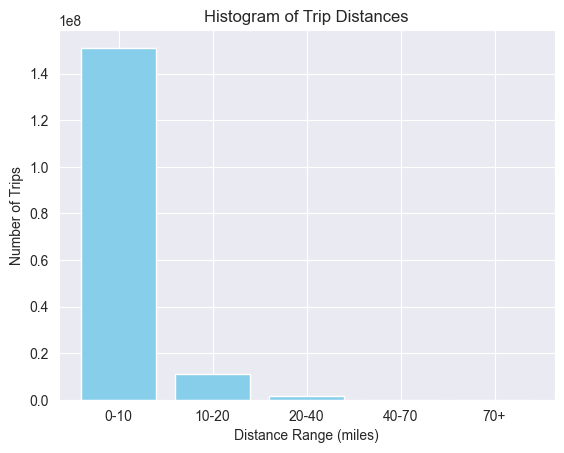

In [31]:
binned_df = df.withColumn(
    "distance_range",
    when((col("trip_distance") >= 0) & (col("trip_distance") <= 10), "0-10")
    .when((col("trip_distance") > 10) & (col("trip_distance") <= 20), "10-20")
    .when((col("trip_distance") > 20) & (col("trip_distance") <= 40), "20-40")
    .when((col("trip_distance") > 40) & (col("trip_distance") <= 70), "40-70")
    .otherwise("70+")
)

counts_df = binned_df.groupBy("distance_range").count().orderBy("distance_range")

counts_pd = counts_df.toPandas()

import matplotlib.pyplot as plt

plt.bar(counts_pd["distance_range"], counts_pd["count"], color="skyblue")
plt.xlabel("Distance Range (miles)")
plt.ylabel("Number of Trips")
plt.title("Histogram of Trip Distances")
plt.show()

In [32]:
counts_pd

,distance_range,count
0,0-10,151091119
1,10-20,10845109
2,20-40,1537096
3,40-70,41454
4,70+,13169


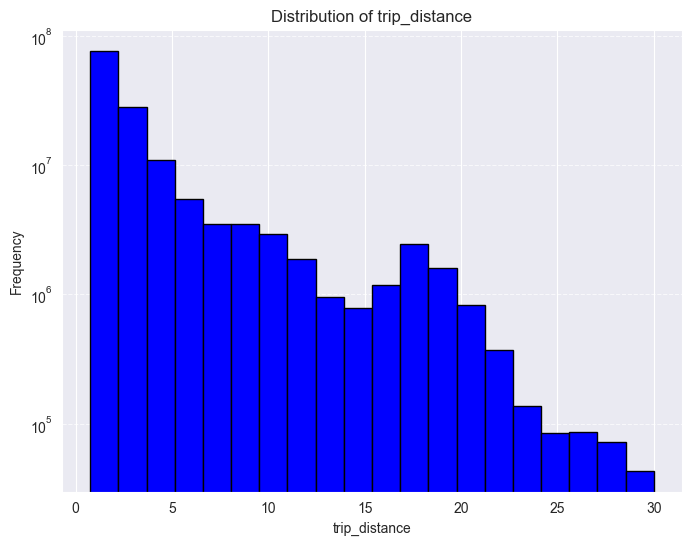

In [33]:
df = df.filter((col("trip_distance") > 0.75) & (col("trip_distance") <= 30))
plot_histogram(df, "trip_distance", log_scale=True, num_bins=20)

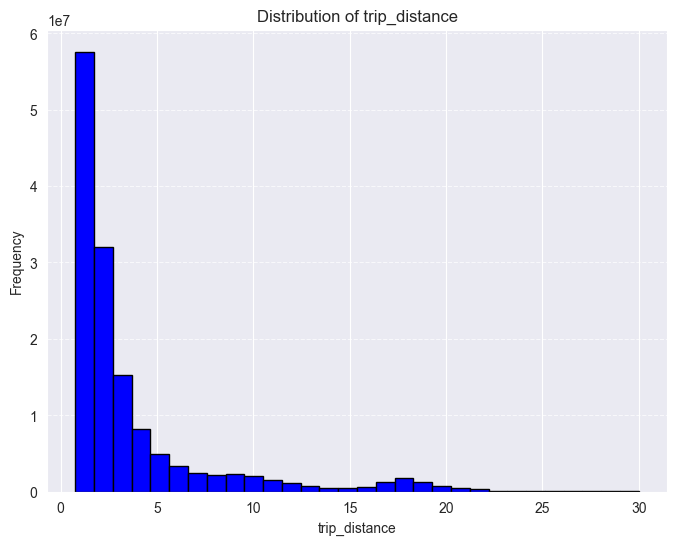

In [34]:
plot_histogram(df, "trip_distance", num_bins=30)

## tip_amount outliers

In [35]:
binned_df = df.withColumn(
        'tips',
        when((col("tip_amount") >= 0) & (col("tip_amount") <= 2), "0-2")
        .otherwise(when((col("tip_amount") > 2) & (col("tip_amount") <= 5), "2-5")
        .otherwise(when((col("tip_amount") > 5) & (col("tip_amount") <= 10), "5-10")
        .otherwise(when((col("tip_amount") > 10) & (col("tip_amount") <= 30), "10-30")
        .otherwise(when((col("tip_amount") > 30) & (col("tip_amount") <= 100), "30-100")
        .otherwise("Other")))
    )))

counts_df = binned_df.groupBy("tips").count().orderBy("tips")

counts_pd = counts_df.toPandas()
counts_pd


,tips,count
0,0-2,59061257
1,10-30,6681318
2,2-5,61583137
3,30-100,55246
4,5-10,14162451
5,Other,2463


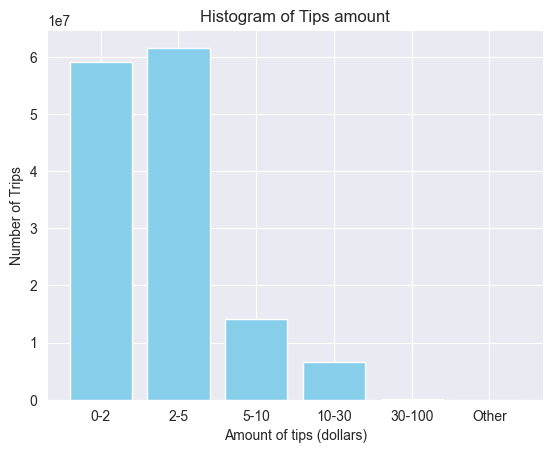

In [36]:
import matplotlib.pyplot as plt

plt.bar(counts_pd.iloc[[0,2,4,1,3,5]]["tips"], counts_pd.iloc[[0,2,4,1,3,5]]["count"], color="skyblue")
plt.xlabel("Amount of tips (dollars)")
plt.ylabel("Number of Trips")
plt.title("Histogram of Tips amount")
plt.show()

In [37]:
df = df.filter((col("tip_amount") >= 0) & (col("tip_amount") <= 30))

## total_amount outliers

In [38]:
binned_df = df.withColumn(
        'total_paid',
        when((col("total_amount") > 0) & (col("total_amount") <= 10), "0-10")
        .otherwise(when((col("total_amount") > 10) & (col("total_amount") <= 20), "10-20")
        .otherwise(when((col("total_amount") > 20) & (col("total_amount") <= 40), "20-40")
        .otherwise(when((col("total_amount") > 40) & (col("total_amount") <= 70), "40-70")
        .otherwise(when((col("total_amount") > 70) & (col("total_amount") <= 150), "70-150")
        .otherwise("Other"))))))

counts_df = binned_df.groupBy("total_paid").count().orderBy("total_paid")

counts_pd = counts_df.toPandas()
counts_pd

,total_paid,count
0,0-10,4889069
1,10-20,72993690
2,20-40,44583476
3,40-70,11275204
4,70-150,6924365
5,Other,822359


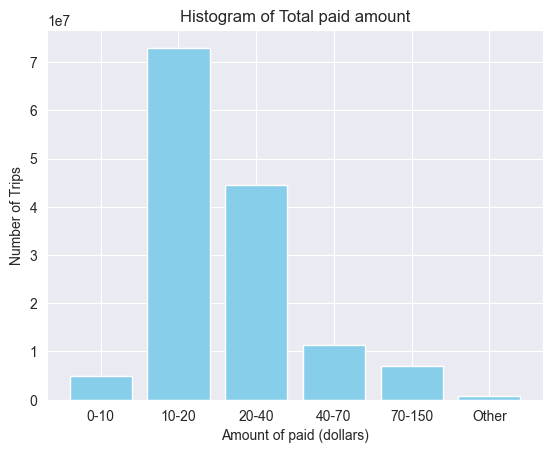

In [39]:
plt.bar(counts_pd["total_paid"], counts_pd["count"], color="skyblue")
plt.xlabel("Amount of paid (dollars)")
plt.ylabel("Number of Trips")
plt.title("Histogram of Total paid amount")
plt.show()

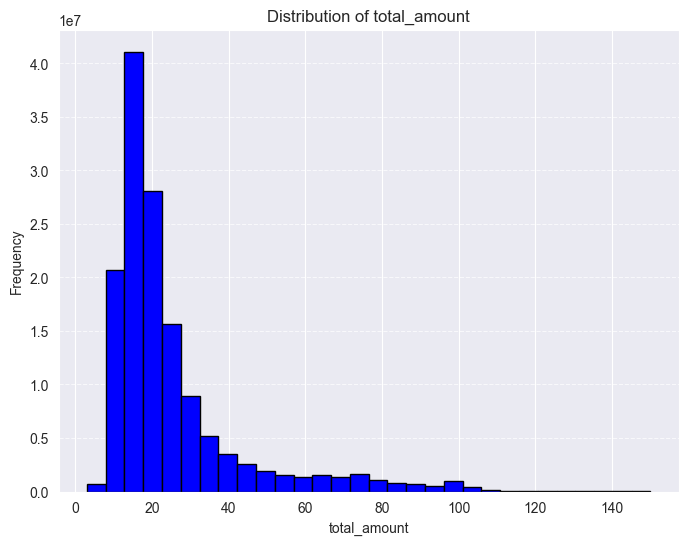

In [40]:
df = df.filter((col("total_amount") >= 3) & (col("total_amount") <= 150))
plot_histogram(df, "total_amount", num_bins=30)

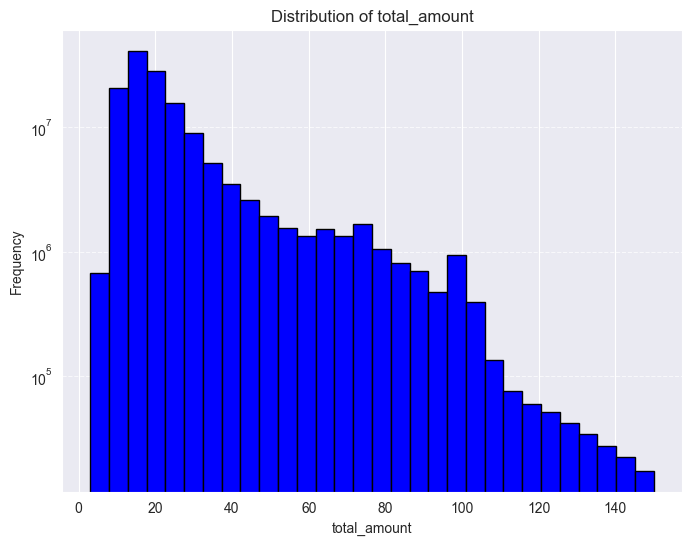

In [41]:
plot_histogram(df, "total_amount", log_scale=True, num_bins=30)

## fare_amount outliers

In [42]:
binned_df = df.withColumn(
        'fares',
        when((col("fare_amount") > 0) & (col("fare_amount") <= 10), "0-10")
        .otherwise(when((col("fare_amount") > 10) & (col("fare_amount") <= 20), "10-20")
        .otherwise(when((col("fare_amount") > 20) & (col("fare_amount") <= 40), "20-40")
        .otherwise(when((col("fare_amount") > 40) & (col("fare_amount") <= 70), "40-70")
        .otherwise(when((col("fare_amount") > 70) & (col("fare_amount") <= 150), "70-150")
        .otherwise("Other"))))))

counts_df = binned_df.groupBy("fares").count().orderBy("fares")

counts_pd = counts_df.toPandas()
counts_pd

,fares,count
0,0-10,52801565
1,10-20,54274983
2,20-40,21925887
3,40-70,10642619
4,70-150,914228
5,Other,54783


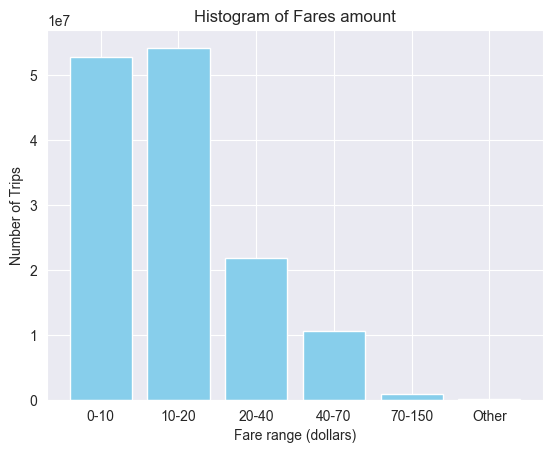

In [43]:
plt.bar(counts_pd["fares"], counts_pd["count"], color="skyblue")
plt.xlabel("Fare range (dollars)")
plt.ylabel("Number of Trips")
plt.title("Histogram of Fares amount")
plt.show()

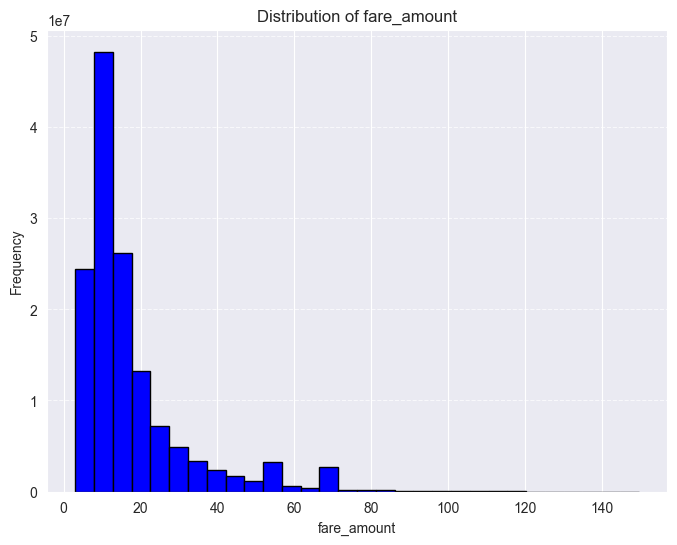

In [44]:
df = df.filter((col("fare_amount") >= 3) & (col("fare_amount") <= 150))
plot_histogram(df, "fare_amount", num_bins=30)

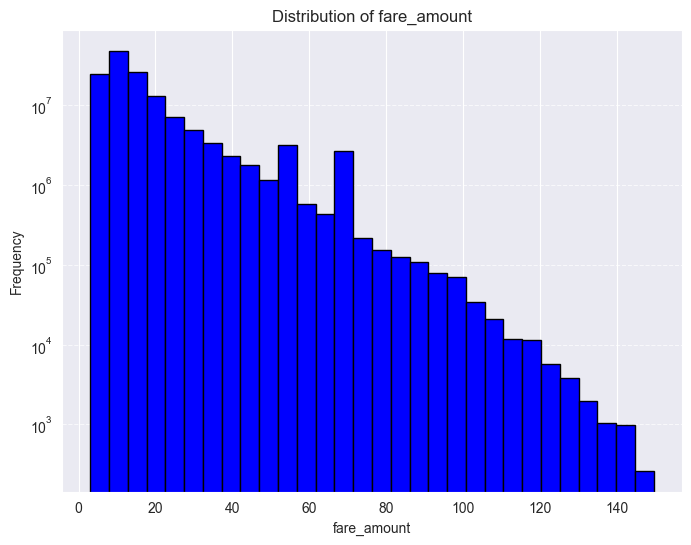

In [45]:
plot_histogram(df, "fare_amount", log_scale=True, num_bins=30)

In [46]:
df.filter(df['fare_amount']==52.0).count()

2514796

In [47]:
df.filter(df['fare_amount']==70.0).count()

2421300

## datetime columns outliers

In [48]:
(df.groupBy(year(col("tpep_pickup_datetime")).alias("year"))).count().show()

+----+--------+
|year|   count|
+----+--------+
|2023|32714603|
|2022|34750829|
|2019|     107|
|2020|20776598|
|2009|     277|
|2024|25266743|
|2002|     326|
|2021|26957979|
|2008|     143|
|2001|      12|
|2098|       1|
|2028|       1|
|2003|      16|
|2011|       3|
|2026|       1|
|2004|       1|
|2029|       1|
|2014|       1|
+----+--------+


In [49]:
df = df.filter((year(col("tpep_pickup_datetime")) >= 2020) & (year(col("tpep_pickup_datetime")) <= 2024) 
).filter((year(col("tpep_dropoff_datetime")) >= 2020) & (year(col("tpep_dropoff_datetime")) <= 2024))

In [50]:
(df.groupBy(year(col("tpep_pickup_datetime")).alias("year"))).count().show()

+----+--------+
|year|   count|
+----+--------+
|2023|32714602|
|2022|34750829|
|2020|20776596|
|2024|25266743|
|2021|26957979|
+----+--------+


## VendorID outliers

In [51]:
(df.groupBy(col("VendorID"))).count().show()

+--------+---------+
|VendorID|    count|
+--------+---------+
|       1| 38547087|
|       6|   232627|
|       5|      298|
|       2|101686737|
+--------+---------+


In [52]:
df = df.filter(col("VendorID").isin(1, 2))
(df.groupBy(col("VendorID"))).count().show()

+--------+---------+
|VendorID|    count|
+--------+---------+
|       1| 38547087|
|       2|101686737|
+--------+---------+


## RatecodeID outliers

In [53]:
(df.groupBy(col("RatecodeID"))).count().show()

+----------+---------+
|RatecodeID|    count|
+----------+---------+
|         1|133846587|
|         3|   364791|
|         5|   287467|
|         4|   198379|
|         2|  4934395|
|        99|   602145|
|         6|       60|
+----------+---------+


In [54]:
df = df.filter((col("RatecodeID") >= 1) & (col("RatecodeID") <= 6))
(df.groupBy(col("RatecodeID"))).count().show()

+----------+---------+
|RatecodeID|    count|
+----------+---------+
|         1|133846587|
|         3|   364791|
|         5|   287467|
|         4|   198379|
|         2|  4934395|
|         6|       60|
+----------+---------+


# passenger_count outliers

In [55]:
df.groupBy("passenger_count").count().orderBy(col("count").desc()).show()

+---------------+---------+
|passenger_count|    count|
+---------------+---------+
|              1|105244119|
|              2| 20168171|
|              3|  5146694|
|              5|  2538697|
|              4|  2532326|
|              0|  2354339|
|              6|  1646974|
|              8|      150|
|              7|      135|
|              9|       72|
|            112|        1|
|             96|        1|
+---------------+---------+


In [56]:
df = df.filter(col("passenger_count") <= 6)
df = df.withColumn(
    "passenger_count",
    when(col("passenger_count") == 0, df.agg(F.median("passenger_count")).collect()[0][0]).otherwise(col("passenger_count"))
)
df.groupBy("passenger_count").count().orderBy(col("count").desc()).show()


+---------------+---------+
|passenger_count|    count|
+---------------+---------+
|            1.0|107598458|
|            2.0| 20168171|
|            3.0|  5146694|
|            5.0|  2538697|
|            4.0|  2532326|
|            6.0|  1646974|
+---------------+---------+


# Creating new features

In [59]:
from pyspark.sql.functions import col, unix_timestamp, round
df = df.withColumn(
    "trip_duration",
    round(((unix_timestamp(col("tpep_dropoff_datetime")) - unix_timestamp(col("tpep_pickup_datetime"))) / 60).cast("double"), 2)
)

# Show the resulting DataFrame
df.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RateCodeID|PULocationID|DOLocationID|payment_type|fare_amount|tip_amount|total_amount|trip_duration|
+--------+--------------------+---------------------+---------------+-------------+----------+------------+------------+------------+-----------+----------+------------+-------------+
|       1| 2020-01-01 00:12:24|  2020-01-01 00:17:10|            1.0|          1.4|         1|         236|         237|           1|        6.0|      2.05|       12.35|         4.77|
|       1| 2020-01-01 00:23:27|  2020-01-01 00:31:55|            2.0|          1.6|         1|         163|         140|           1|        8.0|      2.35|       14.15|         8.47|
|       1| 2020-01-01 00:56:09|  2020-01-01 01:20:27|            1.0|         10

In [58]:
df.select("trip_duration").orderBy(col("trip_duration").desc()).filter(col("trip_duration")>180).count()

187460

In [61]:
df = df.filter(col("trip_duration")<180)

In [62]:
df = df.withColumn("hour", F.hour("tpep_pickup_datetime"))

df = df.withColumn(
    "time_of_day",
    F.when((F.col("hour") >= 6) & (F.col("hour") < 12), "Morning")
     .when((F.col("hour") >= 12) & (F.col("hour") < 18), "Day")
     .when((F.col("hour") >= 18) & (F.col("hour") < 21), "Evening")
     .otherwise("Night")
)

In [63]:
df.count()

139443859

In [64]:
df.write.mode("overwrite").parquet("trip_data_clean.parquet")